# Results

## Narcissus

In [113]:
import pandas as pd
import json
import numpy as np

global_filters = {'noise_eps_narcissus': 8, 
                  }

filters = {'Baseline':{'data_key': 'Baseline'},
            'JPEG 25':{'data_key': 'JPEG[25]'},
            # 'JPEG 50':{'data_key': 'JPEG[50]'},
            # 'JPEG 75':{'data_key': 'JPEG[75]'},
            # 'JPEG 85':{'data_key': 'JPEG[85]'},
            'EBM-150':{'data_key': 'EBM[cinic10_imagenet_ep120_nf32]_Steps[150]_T[0.0001]'},
            # 'EBM-300':{'data_key': 'EBM[cinic10_imagenet_ep120_nf32]_Steps[300]_T[0.0001]'},
            # 'EBM-500':{'data_key': 'EBM[cinic10_imagenet_ep120_nf32]_Steps[500]_T[0.0001]'},
            'HF_DDPM T=10':{'data_key': 'HF_DDPM[google_ddpm-cifar10-32]_T[10]'},
            'HF_DDPM T=25':{'data_key': 'HF_DDPM[google_ddpm-cifar10-32]_T[25]'},
            'HF_DDPM T=50':{'data_key': 'HF_DDPM[google_ddpm-cifar10-32]_T[50]'},
            'HF_DDPM T=75':{'data_key': 'HF_DDPM[google_ddpm-cifar10-32]_T[75]'},
            'HF_DDPM T=100':{'data_key': 'HF_DDPM[google_ddpm-cifar10-32]_T[100]'},
            'HF_DDPM T=125':{'data_key': 'HF_DDPM[google_ddpm-cifar10-32]_T[125]'},
            'HF_DDPM T=150':{'data_key': 'HF_DDPM[google_ddpm-cifar10-32]_T[150]'},
            'HF_DDPM T=200':{'data_key': 'HF_DDPM[google_ddpm-cifar10-32]_T[200]'},
            'DDPM_cifar10-200':{'data_key': 'DM_UNET[cifar10_DDPM[150]_nf[(64, 64, 128, 128, 256, 256)]]_T[200]'},
            'DDPM_cifar10-150':{'data_key': 'DM_UNET[cifar10_DDPM[150]_nf[(64, 64, 128, 128, 256, 256)]]_T[150]'},
            'DDPM_cifar10-125':{'data_key': 'DM_UNET[cifar10_DDPM[150]_nf[(64, 64, 128, 128, 256, 256)]]_T[125]'},
            'DDPM_cifar10-100':{'data_key': 'DM_UNET[cifar10_DDPM[150]_nf[(64, 64, 128, 128, 256, 256)]]_T[100]'},
            'DDPM_cifar10-75':{'data_key': 'DM_UNET[cifar10_DDPM[150]_nf[(64, 64, 128, 128, 256, 256)]]_T[75]'},
            'DDPM_cifar10-50':{'data_key': 'DM_UNET[cifar10_DDPM[150]_nf[(64, 64, 128, 128, 256, 256)]]_T[50]'},
            'DDPM_cifar10-25':{'data_key': 'DM_UNET[cifar10_DDPM[150]_nf[(64, 64, 128, 128, 256, 256)]]_T[25]'},
            'DDPM_cifar10-10':{'data_key': 'DM_UNET[cifar10_DDPM[150]_nf[(64, 64, 128, 128, 256, 256)]]_T[10]'},
}

df = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/Poison_Defense/From_Scratch/Narcissus/Results.csv')
df['Args'] = df['Args'].apply(lambda x: json.loads(x))
df = pd.concat([df.drop(['Args'], axis=1), df['Args'].apply(pd.Series)], axis=1)

# Global filters
for key, value in global_filters.items():
    df = df[df[key] == value]

df_results = []
for label, filter_dict in filters.items():

    df_filt = df
    for key, value in filter_dict.items():
        df_filt = df_filt[df_filt[key] == value]

    df_results.append({'Defense': label,
                        'Nat Acc': f"{df_filt['End Acc'].mean()*100:.2f} \u00B1 {df_filt['End Acc'].std()*100:.2f}",
                        'Poison Success': f"{df_filt['P1 Acc'].mean()*100:.2f} \u00B1 {df_filt['P1 Acc'].std()*100:.2f}",
                        'Max Poison Success': f"{df_filt['P1 Acc'].max()*100:.2f}",
                        'Poisoned Nat Acc': f"{df_filt['T1 Acc'].mean()*100:.2f} \u00B1 {df_filt['T1 Acc'].std()*100:.2f}",
                        'Num Results': len(df_filt),
                    })

df_results = pd.DataFrame(df_results)
df_results

,Defense,Nat Acc,Poison Success,Max Poison Success,Poisoned Nat Acc,Num Results
0,Baseline,92.93 ± 0.13,30.09 ± 35.24,90.41,64.23 ± 31.41,10
1,JPEG 25,88.12 ± 0.20,2.07 ± 1.10,3.97,86.83 ± 0.85,10
2,EBM-150,90.82 ± 0.12,1.63 ± 0.92,3.05,89.48 ± 0.97,10
3,HF_DDPM T=10,nan ± nan,nan ± nan,nan,nan ± nan,0
4,HF_DDPM T=25,nan ± nan,nan ± nan,nan,nan ± nan,0
5,HF_DDPM T=50,nan ± nan,nan ± nan,nan,nan ± nan,0
6,HF_DDPM T=75,nan ± nan,nan ± nan,nan,nan ± nan,0
7,HF_DDPM T=100,nan ± nan,nan ± nan,nan,nan ± nan,0
8,HF_DDPM T=125,nan ± nan,nan ± nan,nan,nan ± nan,0
9,HF_DDPM T=150,nan ± nan,nan ± nan,nan,nan ± nan,0


## Neural Tangent (NTG)

In [121]:
import pandas as pd
import json
import numpy as np

### ToDo Clear Duplicates of cifar-10 runs

df = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/Poison_Defense/From_Scratch/NeuralTangent/Results.csv')
df['Args'] = df['Args'].apply(lambda x: json.loads(x))
df = pd.concat([df.drop(['Args'], axis=1), df['Args'].apply(pd.Series)], axis=1)

filters = {'Baseline':{'data_key': 'Baseline'},
           'JPEG_25':{'data_key': 'JPEG[25]'},
           'EBM_1000':{'data_key': 'EBM[cinic10_imagenet_ep120_nf32]_Steps[1000]_T[0.0001]'},
            'HF_DDPM-200':{'data_key': 'HF_DDPM[google/ddpm-cifar10-32]_T[200]'},
            'HF_DDPM-150':{'data_key': 'HF_DDPM[google/ddpm-cifar10-32]_T[150]'},
            'HF_DDPM-125':{'data_key': 'HF_DDPM[google/ddpm-cifar10-32]_T[125]'},
            'HF_DDPM-100':{'data_key': 'HF_DDPM[google/ddpm-cifar10-32]_T[100]'}, 
            'HF_DDPM-75':{'data_key': 'HF_DDPM[google/ddpm-cifar10-32]_T[75]'},
            'HF_DDPM-50':{'data_key': 'HF_DDPM[google/ddpm-cifar10-32]_T[50]'},
            'HF_DDPM-25':{'data_key': 'HF_DDPM[google/ddpm-cifar10-32]_T[25]'},
            'HF_DDPM-10':{'data_key': 'HF_DDPM[google/ddpm-cifar10-32]_T[10]'},
           'DDPM_cifar10-200':{'data_key': 'DM_UNET[cifar10_DDPM[150]_nf[(64, 64, 128, 128, 256, 256)]]_T[200]'},
            'DDPM_cifar10-150':{'data_key': 'DM_UNET[cifar10_DDPM[150]_nf[(64, 64, 128, 128, 256, 256)]]_T[150]'},
            'DDPM_cifar10-125':{'data_key': 'DM_UNET[cifar10_DDPM[150]_nf[(64, 64, 128, 128, 256, 256)]]_T[125]'},
            'DDPM_cifar10-100':{'data_key': 'DM_UNET[cifar10_DDPM[150]_nf[(64, 64, 128, 128, 256, 256)]]_T[100]'},
            'DDPM_cifar10-75':{'data_key': 'DM_UNET[cifar10_DDPM[150]_nf[(64, 64, 128, 128, 256, 256)]]_T[75]'},
            'DDPM_cifar10-50':{'data_key': 'DM_UNET[cifar10_DDPM[150]_nf[(64, 64, 128, 128, 256, 256)]]_T[50]'},
            'DDPM_cifar10-25':{'data_key': 'DM_UNET[cifar10_DDPM[150]_nf[(64, 64, 128, 128, 256, 256)]]_T[25]'},
            'DDPM_cifar10-10':{'data_key': 'DM_UNET[cifar10_DDPM[150]_nf[(64, 64, 128, 128, 256, 256)]]_T[10]'},
}

df_results = []
for label, filter_dict in filters.items():

    df_filt = df
    for key, value in filter_dict.items():
        if value == 'NaN':
            df_filt = df_filt[df_filt[key].isnull()]
        else:
            df_filt = df_filt[df_filt[key] == value]


    df_results.append({'Defense': label,
                        'Nat Acc': f"{df_filt['End Acc'].mean()*100:.2f} \u00B1 {df_filt['End Acc'].std()*100:.2f}",
                    'Num Results': len(df_filt),
                    })
        
df_results = pd.DataFrame(df_results)
df_results

,Defense,Nat Acc,Num Results
0,Baseline,14.35 ± 1.07,8
1,JPEG_25,77.09 ± 0.54,8
2,EBM_1000,82.67 ± 0.38,8
3,HF_DDPM-200,85.54 ± 0.31,8
4,HF_DDPM-150,87.21 ± 0.16,8
5,HF_DDPM-125,87.50 ± 0.37,8
6,HF_DDPM-100,87.73 ± 0.32,8
7,HF_DDPM-75,87.18 ± 0.27,8
8,HF_DDPM-50,84.52 ± 0.38,8
9,HF_DDPM-25,72.00 ± 0.37,8


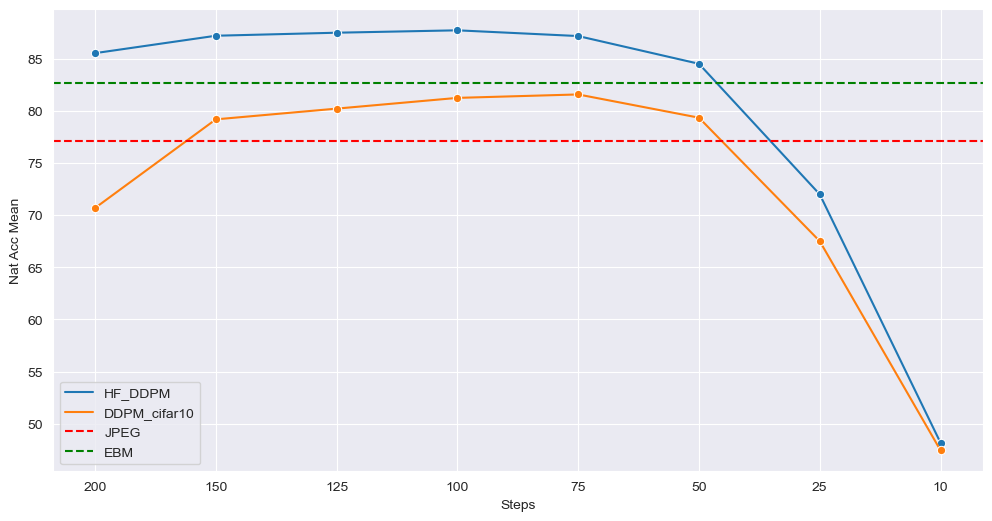

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

dm_plot = df_results.copy()
dm_plot['Label'] = dm_plot['Defense'].apply(lambda x: x.split('-')[0])
dm_plot['Steps'] = dm_plot['Defense'].apply(lambda x: x.split('-')[1] if len(x.split('-')) > 1 else 0)
dm_plot['Nat Acc Mean'] = dm_plot['Nat Acc'].apply(lambda x: float(x.split(' ')[0]))

# Filter out 0 steps
dm_plot_diff = dm_plot[dm_plot['Steps'] != 0]

# PLot x_axis steps, y axis Nat Acc, and hue as Label
plt.figure(figsize=(12, 6))
sns.lineplot(data=dm_plot_diff, x='Steps', y='Nat Acc Mean', hue='Label', marker='o')

# Draw Hlines for EBM and JPEG
plt.axhline(y=dm_plot[dm_plot['Defense'] == 'JPEG_25']['Nat Acc Mean'].values[0], color='r', linestyle='--', label='JPEG')
plt.axhline(y=dm_plot[dm_plot['Defense'] == 'EBM_1000']['Nat Acc Mean'].values[0], color='g', linestyle='--', label='EBM')

plt.legend()

,Defense,Nat Acc,Num Results
0,Baseline,14.35 ± 1.07,8
1,JPEG_25,77.09 ± 0.54,8
2,EBM_1000,82.67 ± 0.38,8
3,HF_DDPM-200,85.54 ± 0.31,8
4,HF_DDPM-150,87.21 ± 0.16,8
5,HF_DDPM-125,87.50 ± 0.37,8
6,HF_DDPM-100,87.73 ± 0.32,8
7,HF_DDPM-75,87.18 ± 0.27,8
8,HF_DDPM-50,84.52 ± 0.38,8
9,HF_DDPM-25,72.00 ± 0.37,8


3     70.69
4     79.19
5     80.22
6     81.25
7     81.58
8     79.35
9     67.51
10    47.45
11    85.54
12    87.21
13    87.50
14    87.73
15    87.18
16    84.52
17    72.00
18    48.18
19    70.89
20    75.97
21    77.81
22    78.96
23    79.91
24    77.88
25    67.88
26    50.24
27    69.40
28    79.11
29    80.73
30    81.45
31    82.33
32    80.86
33    69.69
34    47.45
Name: Nat Acc, dtype: float64

## Baseline Narc

In [3]:
# Model filters
MODEL = 'HLB_S'

df = pd.read_csv('/home/sunaybhat/results_PureGen_PoisonDefense/Clean/Narcissus/Results.csv')
df['Args'] = df['Args'].apply(lambda x: json.loads(x))
df = pd.concat([df.drop(['Args'], axis=1), df['Args'].apply(pd.Series)], axis=1)
# Filter by model
df = df[(df['Model'] == MODEL)]

df_results = []

df_filt = df


df_results.append({'Defense': 'Baseline',
                    'Nat Acc': f"{df_filt['End Acc'].mean()*100:.2f} \u00B1 {df_filt['End Acc'].std()*100:.2f}",
                    'Poison Success': f"{df_filt['P1 Acc'].mean()*100:.2f} \u00B1 {df_filt['P1 Acc'].std()*100:.2f}",
                    'Max Poison Success': f"{df_filt['P1 Acc'].max()*100:.2f}",
                    'Poisoned Nat Acc': f"{df_filt['T1 Acc'].mean()*100:.2f} \u00B1 {df_filt['T1 Acc'].std()*100:.2f}",
                    'Num Results': len(df_filt),
                })

df_results = pd.DataFrame(df_results)
df_results

,Defense,Nat Acc,Poison Success,Max Poison Success,Poisoned Nat Acc,Num Results
0,Baseline,93.13 ± 0.00,1.43 ± 1.34,4.10,88.42 ± 3.02,10
